In [50]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding,Activation,GlobalMaxPooling1D, SpatialDropout1D,GRU,Bidirectional,BatchNormalization

We`ll perform sentiment analysis on a corpus of movie reviews. We’re asked to label each phrase on a scale of zero to four. The sentiment corresponding to each of the labels are:


0: negative

1: somewhat negative

2: neutral

3: somewhat positive

4: positive


In [41]:
df_train = pd.read_csv('/content/train.tsv', sep='\t')
print('train set: {0}'.format(df_train.shape))
df_train.head(10)

train set: (156060, 4)


,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2
5,6,1,of escapades demonstrating the adage that what...,2
6,7,1,of,2
7,8,1,escapades demonstrating the adage that what is...,2
8,9,1,escapades,2
9,10,1,demonstrating the adage that what is good for ...,2


In [42]:
df_test = pd.read_csv('/content/test.tsv', sep='\t')
print('test set: {0}'.format(df_test.shape))
df_test.head(10)

test set: (66292, 3)


,PhraseId,SentenceId,Phrase
0,156061,8545,An intermittently pleasing but mostly routine ...
1,156062,8545,An intermittently pleasing but mostly routine ...
2,156063,8545,An
3,156064,8545,intermittently pleasing but mostly routine effort
4,156065,8545,intermittently pleasing but mostly routine
5,156066,8545,intermittently pleasing but
6,156067,8545,intermittently pleasing
7,156068,8545,intermittently
8,156069,8545,pleasing
9,156070,8545,but


In [43]:
replace_list = {r"i'm": 'i am',
                r"'re": ' are',
                r"let’s": 'let us',
                r"'s":  ' is',
                r"'ve": ' have',
                r"can't": 'can not',
                r"cannot": 'can not',
                r"shan’t": 'shall not',
                r"n't": ' not',
                r"'d": ' would',
                r"'ll": ' will',
                r"'scuse": 'excuse',
                ',': ' ,',
                '.': ' .',
                '!': ' !',
                '?': ' ?',
                '\s+': ' '}
def clean_text(text):
    text = text.lower()
    for s in replace_list.keys():
        text = text.replace(s, replace_list[s])

    return text

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1648/1206190028.py:17: SyntaxWarning: invalid escape sequence '\s'
  '\s+': ' '}


In [44]:
X_train = df_train['Phrase'].apply(lambda p: clean_text(p))

max phrase len: 60


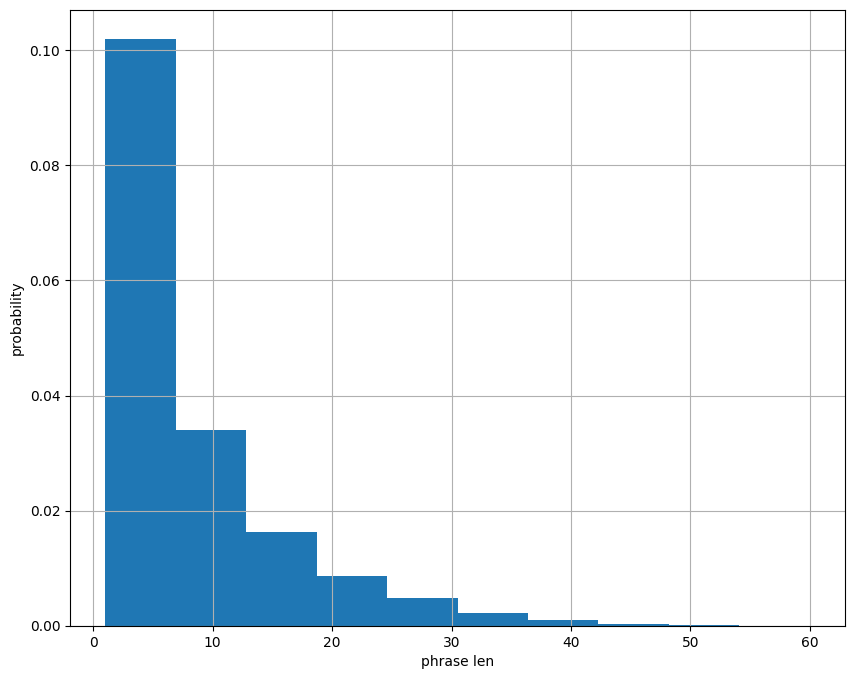

In [45]:
phrase_len = X_train.apply(lambda p: len(p.split(' ')))
max_phrase_len = phrase_len.max()
print('max phrase len: {0}'.format(max_phrase_len))
plt.figure(figsize = (10, 8))
plt.hist(phrase_len, density = True)
plt.xlabel('phrase len')
plt.ylabel('probability')
plt.grid()

In [46]:
y_train = df_train['Sentiment']

In [47]:
max_words = 8192
tokenizer = Tokenizer(
    num_words = max_words,
    filters = '"#$%&()*+-/:;<=>@[\]^_`{|}~'
)
tokenizer.fit_on_texts(X_train)
X_train = tokenizer.texts_to_sequences(X_train)
X_train = pad_sequences(X_train, maxlen = max_phrase_len)
y_train = to_categorical(y_train)

<>:4: SyntaxWarning: invalid escape sequence '\]'
<>:4: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_1648/2235018941.py:4: SyntaxWarning: invalid escape sequence '\]'
  filters = '"#$%&()*+-/:;<=>@[\]^_`{|}~'


In [48]:
batch_size = 512


In [53]:
model_lstm = Sequential([
    Embedding(max_words, 128, input_length=max_phrase_len),

    SpatialDropout1D(0.3),

    Bidirectional(
        GRU(
            128,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    ),

    GlobalMaxPooling1D(),

    Dense(128),
    BatchNormalization(),
    Activation("relu"),

    Dropout(0.5),

    Dense(5, activation="softmax")
])

In [55]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

early = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)

In [56]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-3)
model_lstm.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [57]:
history = model_lstm.fit(
    X_train,
    y_train,
    validation_split = 0.1,
    epochs = 10,
    batch_size = 2050,callbacks=[early,reduce]
)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 35s 394ms/step - accuracy: 0.4812 - loss: 1.2943 - val_accuracy: 0.4899 - val_loss: 1.4581 - learning_rate: 0.0010
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 39s 381ms/step - accuracy: 0.6097 - loss: 0.9814 - val_accuracy: 0.5022 - val_loss: 1.3343 - learning_rate: 0.0010
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 42s 389ms/step - accuracy: 0.6436 - loss: 0.8838 - val_accuracy: 0.5313 - val_loss: 1.2736 - learning_rate: 0.0010
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 28s 400ms/step - accuracy: 0.6602 - loss: 0.8413 - val_accuracy: 0.5670 - val_loss: 1.2164 - learning_rate: 0.0010
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 28s 396ms/step - accuracy: 0.6700 - loss: 0.8136 - val_accuracy: 0.5829 - val_loss: 1.1264 - learning_rate: 0.0010
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 27s 392ms/step - accuracy: 0.6766 - loss: 0.7923 - val_accuracy: 0.6028 - val_loss: 1.0649 - learning_rate: 0.0010
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 27s 387ms/step - accuracy: 0.6840 - loss: 0.

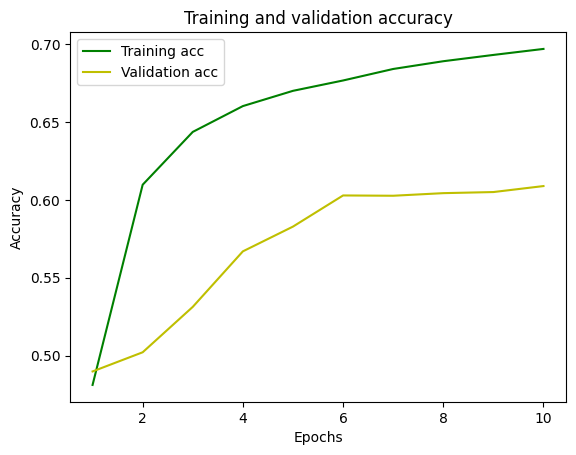

In [58]:
plt.clf()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'g', label='Training acc')
plt.plot(epochs, val_acc, 'y', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [59]:
x_test=df_test['Phrase'].apply(lambda p: clean_text(str(p)))
x_test=tokenizer.texts_to_sequences(x_test)
x_test=pad_sequences(x_test,maxlen=max_phrase_len)
pred=model_lstm.predict(x_test)
index=np.argmax(pred,axis=1)
df_test['Sentiment']=index
df_test.to_csv('submission.csv',columns=['PhraseId','Sentiment'],index=False)
#
df_test.head()

2072/2072 ━━━━━━━━━━━━━━━━━━━━ 160s 77ms/step


,PhraseId,SentenceId,Phrase,Sentiment
0,156061,8545,An intermittently pleasing but mostly routine ...,2
1,156062,8545,An intermittently pleasing but mostly routine ...,2
2,156063,8545,An,2
3,156064,8545,intermittently pleasing but mostly routine effort,2
4,156065,8545,intermittently pleasing but mostly routine,2
